# 1. Single image analysis

In [ ]:
from traitly.internal_structure import FruitAnalyzer


In [ ]:
path = '/Users/alejandra/Downloads/IMG_20250726_0004.jpg'
cranberry = FruitAnalyzer(path)

cranberry.read_image(plot = False)

In [ ]:
cranberry.setup_measurements(diameter_cm = 1.7)


1. LABEL DETECTION:
> No QR detected.
> Label text detection: SKIPPED (label=False)

2. REFERENCE SIZE:
Image dimensions:
    - Width:  2,550 pixels
    - Length: 3,300 pixels

No size reference detected.
Missing parameters: width_cm, length_cm

 IMPORTANT: Measurements will be returned in >> PIXEL << units


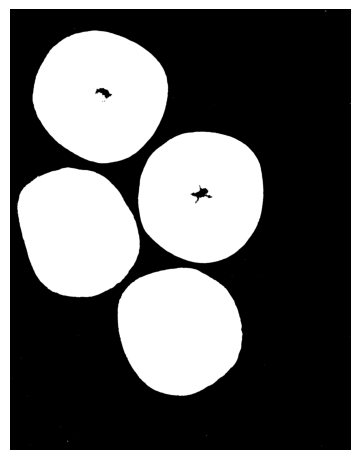

In [ ]:
cranberry.create_mask(plot = True, kernel_blur = 1)

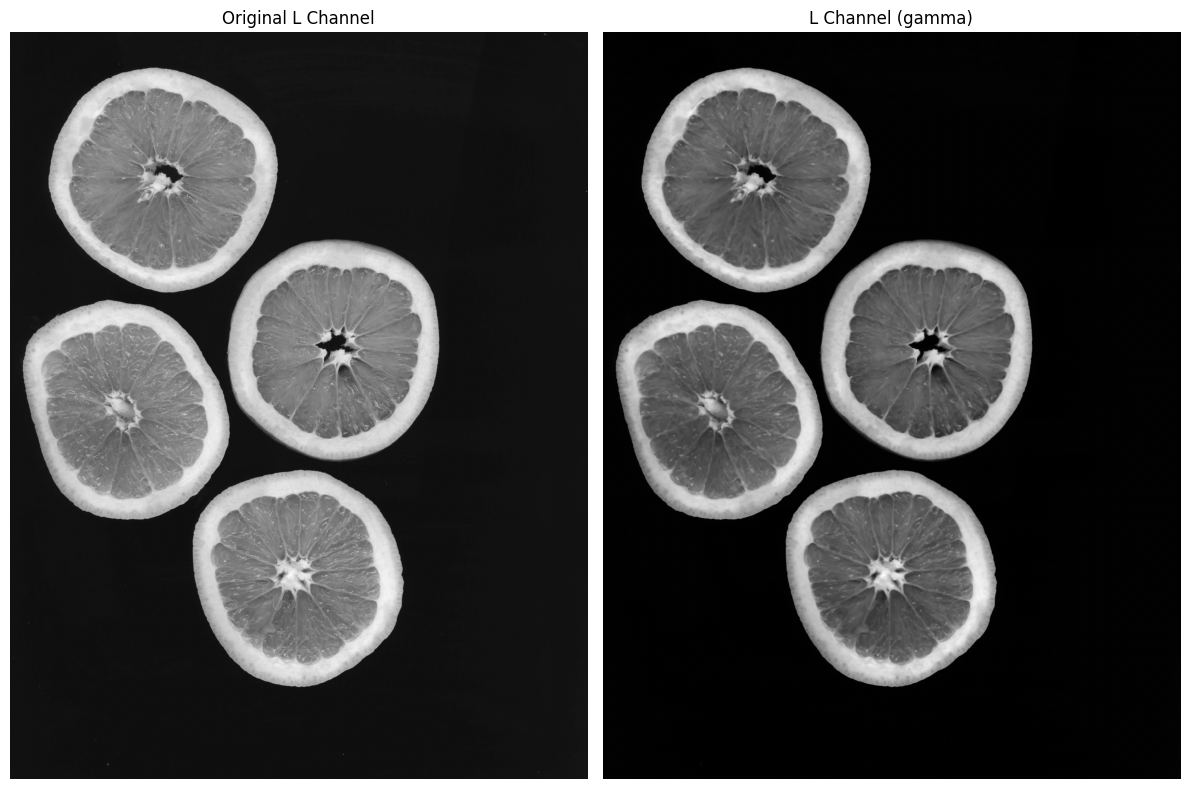

In [ ]:
cranberry.apply_contrast(contrast_method = 'gamma', plot = True, kernel_blur = 7)

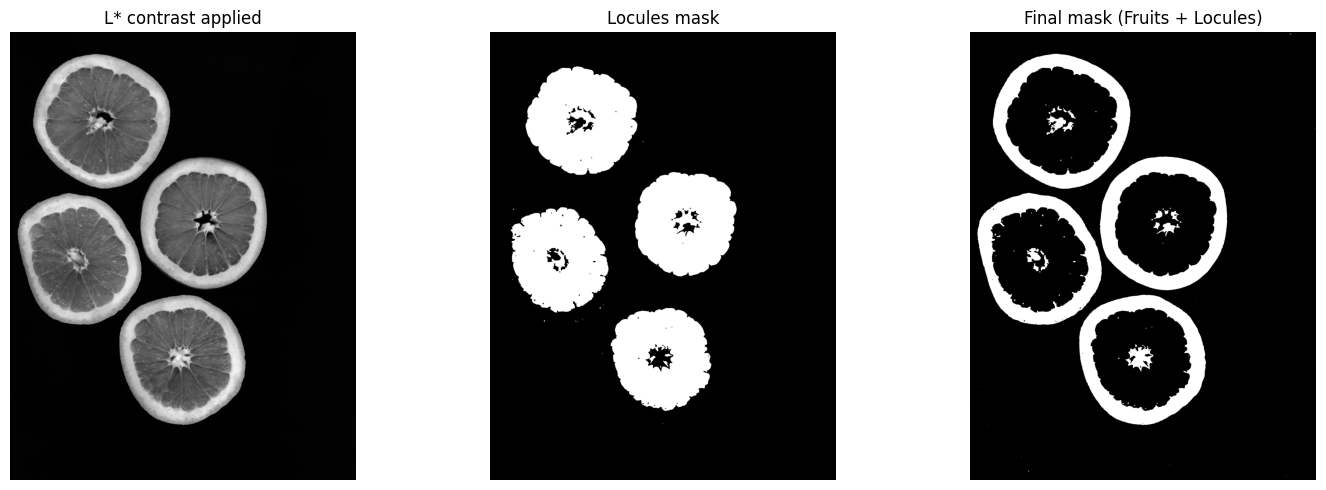

In [ ]:
cranberry.create_mask_locules(plot = True, kernel_close = 6)

In [ ]:
cranberry.find_fruits(min_circularity = 0.1, min_locule_area = 50)

Total detected objects: 155
Detected fruits after filtering: 4


Debug fruit data: Ok!
Debug fruit metrics: Ok!
Debug pericarp metrics: Ok!
Debug symmetry metrics: Ok!
Error processing fruit 33: float division by zero
Debug fruit data: Ok!
Debug fruit metrics: Ok!
Debug pericarp metrics: Ok!
Debug symmetry metrics: Ok!
Error processing fruit 72: float division by zero
Debug fruit data: Ok!
Debug fruit metrics: Ok!
Debug pericarp metrics: Ok!
Debug symmetry metrics: Ok!
Error processing fruit 106: float division by zero
Debug fruit data: Ok!
Debug fruit metrics: Ok!
Debug pericarp metrics: Ok!
Debug symmetry metrics: Ok!
Error processing fruit 130: float division by zero


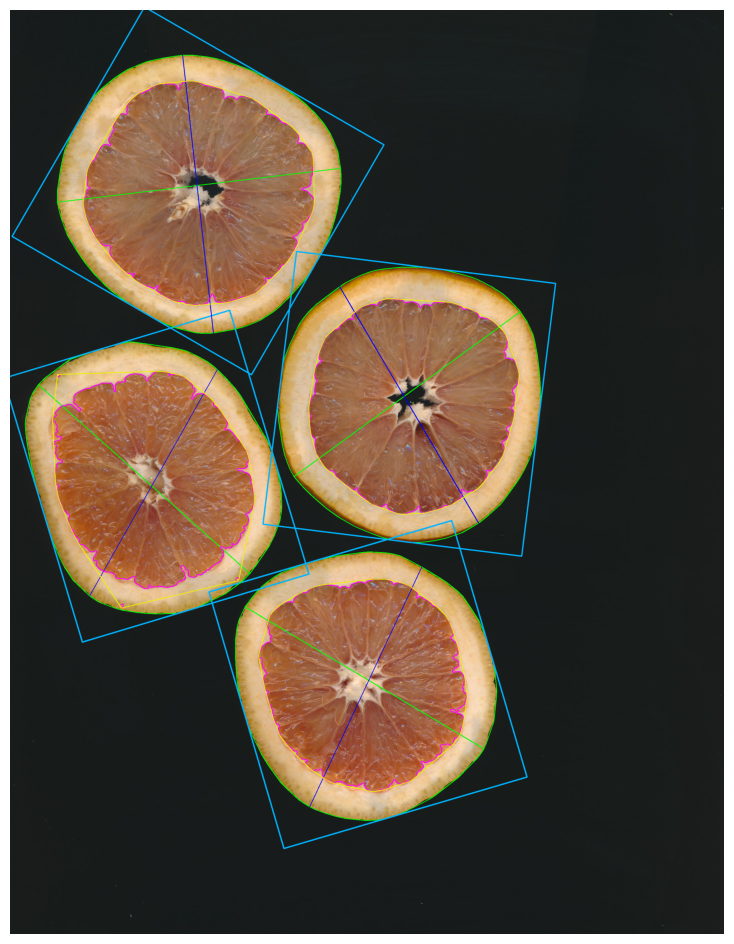

In [ ]:
cranberry.analyze_image(plot_size = (12,12), plot = True, contour_mode = 'hull', min_locule_area = 50)

In [12]:
import pandas as pd

pd.DataFrame(cranberry.results.results)

""


In [77]:
cranberry.results.save_all()

# cranberry.results.save_img() # Save only the annotated_image
# cranberry.results.save_csv() # Save only the csv results table

Image saved at: /Users/alejandra/Documents/traitly/tests/sample_data/img_test_1_annotated.jpg
CSV saved at: /Users/alejandra/Documents/traitly/tests/sample_data/img_test_1_results.csv
Error report saved at: /Users/alejandra/Documents/traitly/tests/sample_data/error_report.csv
Session report saved at: /Users/alejandra/Documents/traitly/tests/sample_data/session_report.txt


# 2. Batch analysis

In [33]:
path = '/Users/alejandra/Documents/traitly/tests/sample_data'
cranberry_batch = FruitAnalyzer(path)

cranberry_batch.analyze_folder()

Traitly running ⋆✧｡٩(ˊᗜˋ )و✧*｡   
Sequential mode: processing 6 image(s) one at a time


Processing images: 100%|██████████| 6/6 [00:11<00:00,  1.94s/image]


 ( ദ്ദി ˙ᗜ˙ )   Processing completed !
══════════════════════════════════════════════════════════════════════
- Total time: 0.19 minutes (~1.94 sec/image)
-  Total images processed: 6
- Successfully annotated: 5
- Failed (errors): 1
- RAM used: 0.01 GB (peak: 1.43 GB)
> Output folder: /Users/alejandra/Documents/traitly/tests/sample_data/Results
> Error report saved in: /Users/alejandra/Documents/traitly/tests/sample_data/Results/error_report.csv


# 3. Stamp analysis


LABEL DETECTION:
> No QR detected.
> Label text detection: SKIPPED (label=False)

REFERENCE SIZE:
Image dimensions:
    - Width:  2,478 pixels
    - Length: 3,231 pixels

No size reference detected.
Missing parameters: width_cm, length_cm

 IMPORTANT: Measurements will be returned in >> PIXEL << units
Total detected objects: 175
Detected fruits after filtering: 21


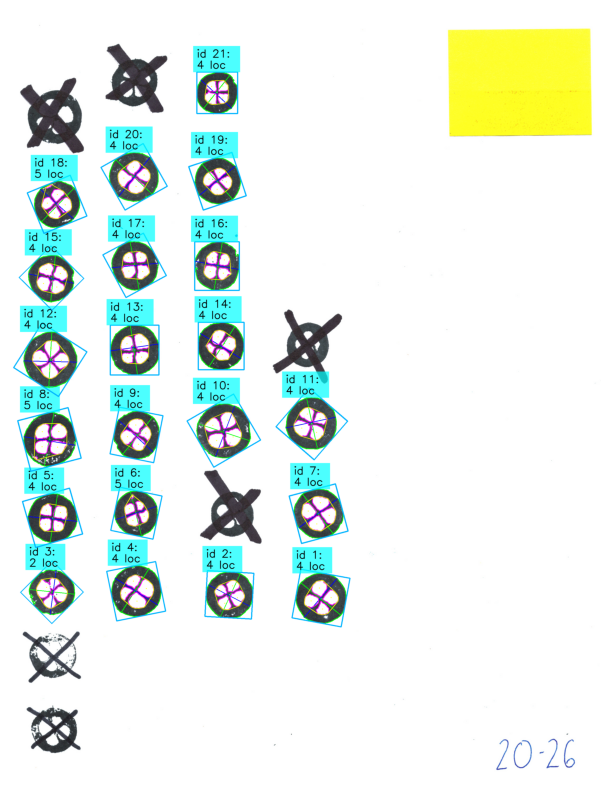

In [ ]:
path_stamp = '/Users/alejandra/Documents/traitly/tests/sample_data/stamp/img_test_6.jpg'

cranberry_stamp = FruitAnalyzer(path_stamp)
cranberry_stamp.read_image()
cranberry_stamp.setup_measurements()
cranberry_stamp.create_mask(stamp = True) # <- declare that the input are stamps 
cranberry_stamp.find_fruits()
cranberry_stamp.analyze_image(label_color = (255,255,0)) # Change label color from white to cyan

# 4. Fruits with complex locules analysis

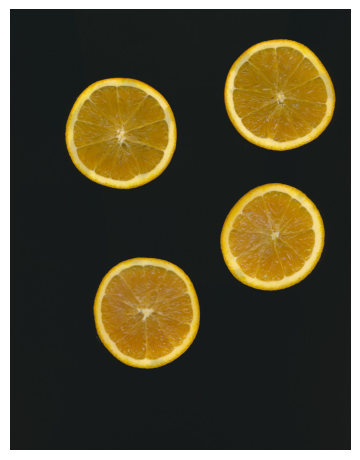


LABEL DETECTION:
> No QR detected.
> Label text detection: SKIPPED (label=False)

REFERENCE SIZE:
Image dimensions:
    - Width:  3,400 pixels
    - Length: 4,400 pixels

No size reference detected.
Reference circles not detected. Using provided physical dimensions:
    - Width:  21.5 cm
    - Length: 27.9 cm

>>> Calculated px/cm density: 157.92 px/cm


In [43]:
path_orange = '/Users/alejandra/Documents/traitly/tests/sample_data/orange.jpg'

orange = FruitAnalyzer(path_orange)
orange.read_image(plot = True)
orange.setup_measurements(width_cm = 21.5, length_cm = 27.9)


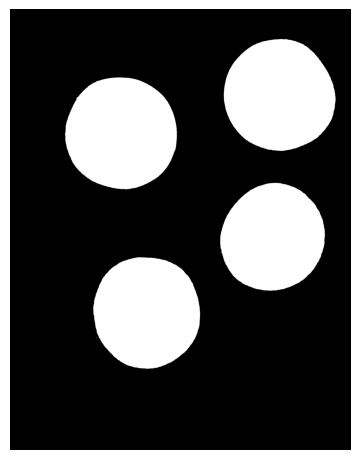

In [ ]:
orange.create_mask(plot = True) # Fruit mask created

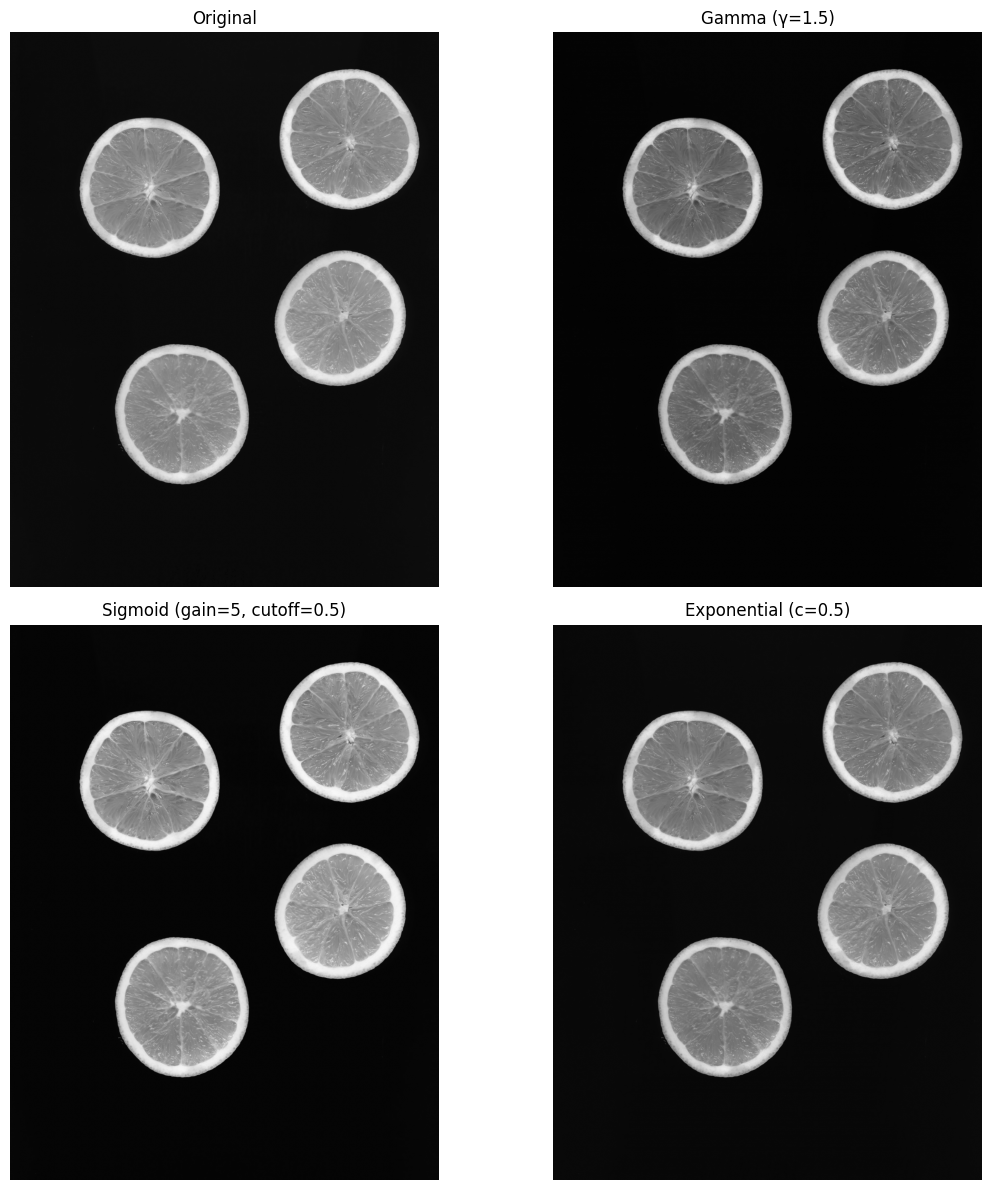

In [ ]:
# Apply bw contrast to segment only the locules 

# First, compare contrast methods available and choose the best one for your fruits:
orange.apply_contrast(plot = True, compare = True) 

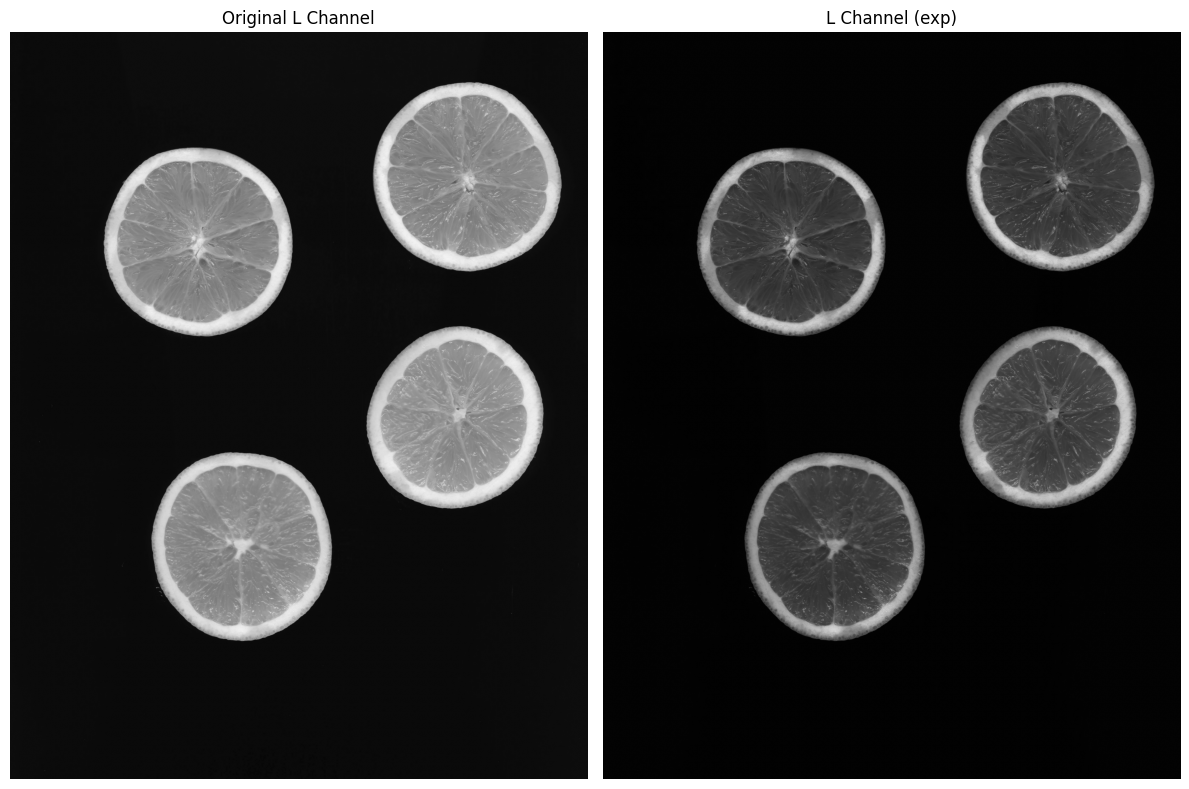

In [ ]:
# Then, apply that specific method on your image
orange.apply_contrast(contrast_method = 'exp', c = 3, plot = True)

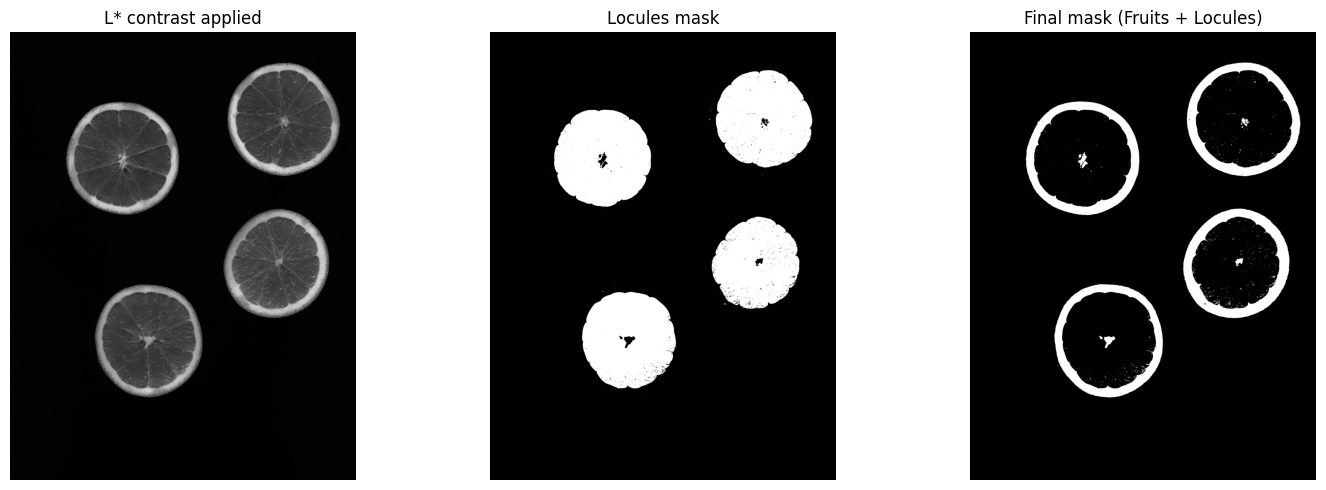

In [51]:
orange.create_mask_locules(plot = True)

Total detected objects: 2141
Detected fruits after filtering: 4


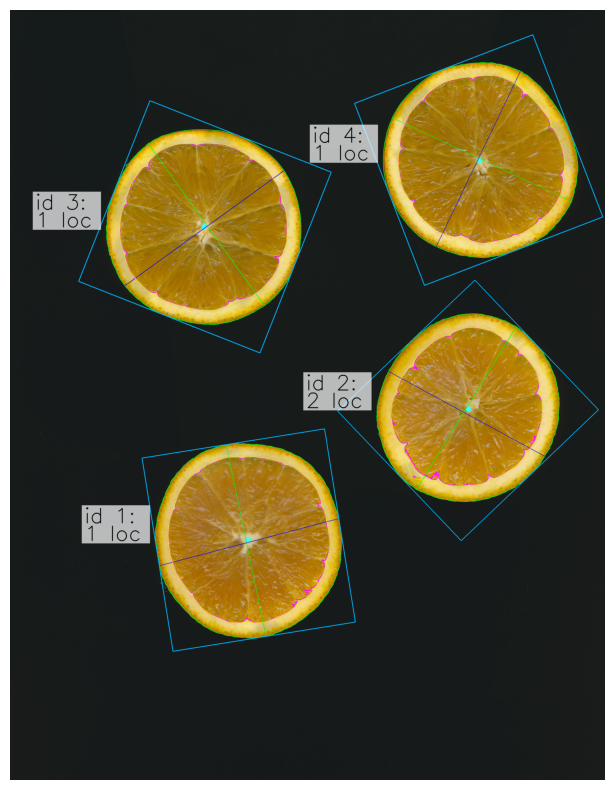

In [ ]:
orange.find_fruits()
orange.analyze_image(font_scale = 4, 
                     font_thickness = 3, 
                     label_position = 'left', 
                     centroid_fruit = 15) # Centroid dot size 